Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 7: Pengantar Machine Learning — Regresi Linear


## Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport')


Library berhasil diimport


## Langkah 1: Generate & Eksplorasi Dataset

Buat dataset sintetis prediksi gaji berdasarkan pengalaman kerja, pendidikan, dan kota.


Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


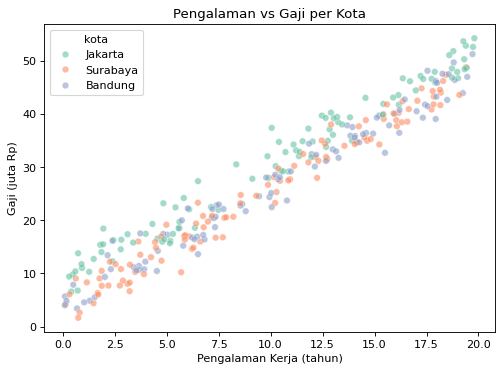

In [2]:
# Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu
        + np.where(kota == 'Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja (tahun)')
plt.ylabel('Gaji (juta Rp)')
plt.tight_layout()
plt.show()


## Langkah 2: Preprocessing

Terapkan One-Hot Encoding pada `kota`, lakukan train-test split, dan scaling dengan StandardScaler.


In [3]:
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


## Langkah 3: Latih Model & Tampilkan Koefisien

Latih model `LinearRegression` dan tampilkan koefisien setiap fitur.


In [4]:
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))


β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


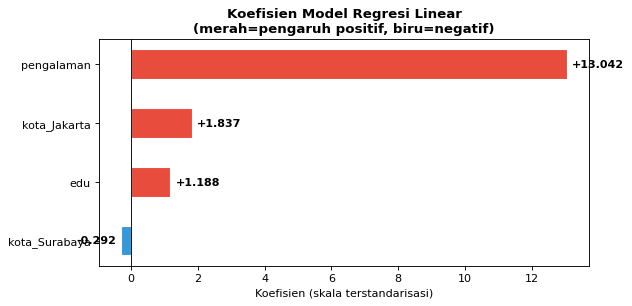

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#E74C3C' if v > 0 else '#3498DB' for v in coef_df['Koefisien']]
bars = ax.barh(coef_df['Fitur'], coef_df['Koefisien'],
               color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, coef_df['Koefisien']):
    offset = 0.15 if val >= 0 else -0.15
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10, fontweight='bold')
ax.set_xlabel('Koefisien (skala terstandarisasi)')
ax.set_title('Koefisien Model Regresi Linear\n(merah=pengaruh positif, biru=negatif)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Langkah 4: Evaluasi Model

Hitung metrik MAE, RMSE, dan R² pada data test.


In [6]:
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse - mae:.3f}')


=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## Langkah 5: Visualisasi & Interpretasi

Buat plot Actual vs Predicted dan Residual Plot untuk menilai performa model.


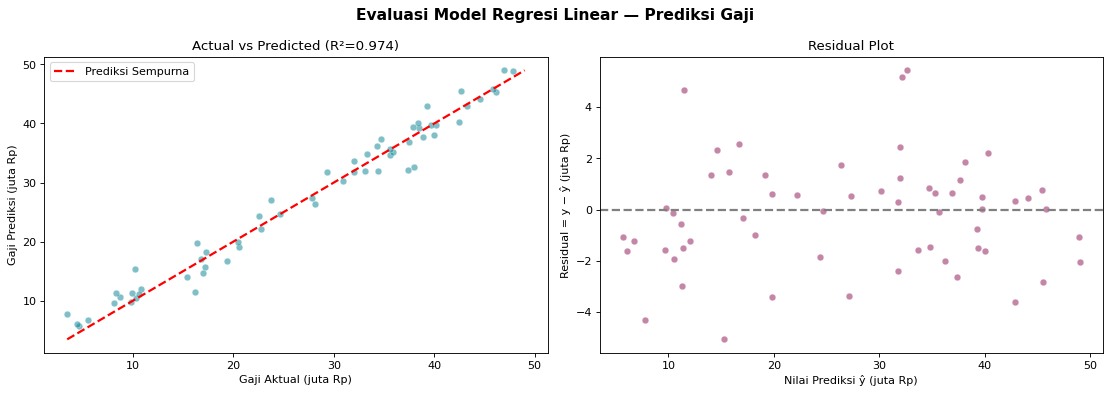

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()


## Kesimpulan

### Apa yang Dipelajari
- Membangun model **Regresi Linear** untuk memprediksi gaji
- Preprocessing: One-Hot Encoding, train-test split, StandardScaler
- Evaluasi model dengan MAE, RMSE, dan R²
- Visualisasi Actual vs Predicted dan Residual Plot

### Temuan Utama
- Model mencapai R² = 0.974 — 97.4% variasi gaji berhasil dijelaskan
- `pengalaman` dan `edu` berkontribusi positif terhadap prediksi gaji
- Residual tersebar acak di sekitar nol — asumsi linearitas relatif terpenuhi

### Keterbatasan
- Dataset sintetis, belum merepresentasikan kondisi pasar kerja nyata
- Model linear belum menangkap interaksi kompleks antar variabel
- Perlu uji model lain (Random Forest, dll.) untuk perbandingan
